# 浙江省县级水污染治理政策文本分析（Data + NLP）

## 1 项目背景
本 Notebook 以县级水污染治理政策文本为对象，通过自动化汇集并整合来自不同市县政府发布的政策文件（docx），构建规范化文本数据集，为后续的政策量化分析提供基础。

主要内容包括：
- 自动化文档抽取与结构化处理
- 文本清洗与中文预处理
- 分词与关键词特征提取（TF-IDF）
- 政策工具识别与分类
- 时间维度的政策演化分析
- 区域差异与政策偏好比较

---

## 2 主要技术路线

1. 数据收集与结构化
	•	批量读取县域政策文档
	•	提取城市、县区与年份信息
	•	获取正文文本

2. 文本预处理
	•	基础清洗与中文提取
	•	中文分词与停用词处理

3. NLP 与政策分析
	•	关键词提取与文本向量化（TF-IDF）
	•	政策工具识别与分类
	•	时间与区域维度的变化趋势分析

# Policy Text Analysis of County-Level Water Pollution Governance in Zhejiang Province (Data + NLP)

## 1 Background
This notebook analyzes county-level government policies on water pollution control. Policy documents are collected in .docx format and organized by city and county. The aim is to build a structured policy text dataset and conduct quantitative policy analysis based on natural language processing.

Key components include:
- Automated document extraction and structuring
- Text cleaning and Chinese preprocessing
- Tokenization and TF-IDF feature representation
- Rule-based classification of policy instruments
- Temporal analysis of policy evolution
- Regional comparison of policy orientation
  
---

## 2 Methodological Workflow

1. Data collection and structuring
	•	Batch processing of county-level policy documents
	•	Extraction of city/county/year metadata
	•	Retrieval of policy text content

2. Text preprocessing
	•	Basic cleaning and Chinese text extraction
	•	Tokenization and stopwords removal

3. NLP and policy analysis
	•	TF-IDF based keyword representation
	•	Rule-based classification of policy instruments
	•	Temporal and spatial trend analysis

In [1]:
import os, docx, pandas as pd
import re

BASE = "/Users/tsy_02/Desktop/县级政策文件整理"  


# --- function to read .docx text ---
def read_docx(path):
    try:
        doc = docx.Document(path)
        return "\n".join([p.text.strip() for p in doc.paragraphs])
    except:
        return ""

# --- function to extract year from filename --
def extract_year(fname):
    m = re.search(r"(20\d{2}|19\d{2})", fname)
    return m.group(1) if m else None

records = []

for city in os.listdir(BASE):
    city_path = os.path.join(BASE, city)
    if not os.path.isdir(city_path): continue

    for county in os.listdir(city_path):
        county_dir = os.path.join(city_path, county)
        if not os.path.isdir(county_dir): continue
        
        for fname in os.listdir(county_dir):
            if not fname.endswith(".docx"): continue

            f = os.path.join(county_dir, fname)
            text = read_docx(f)
            year = extract_year(fname)

            records.append({
                "city": city,
                "county": county,
                "filename": fname,
                "year": year,
                "text": text
            })

df = pd.DataFrame(records)
df.to_csv("/Users/tsy_02/Desktop/policy_raw.csv", index=False)
df.head()

,city,county,filename,year,text
0,宁波市,慈溪市,2014-关于印发慈溪市农村污水治理三年行动计划（2014—2016）的通知.docx,2014,\n\n\n\n\n关于印发慈溪市农村污水治理三年行动计划（2014—2016）的通知\n各...
1,宁波市,慈溪市,2014-关于印发《2014年慈溪市“五水共治”工作总结》的通知.docx,2014,\n\n\n\n\n关于印发《2014年慈溪市“五水共治”工作总结》的通知\n综合组、各专业...
2,宁波市,慈溪市,2011-市政府办公室关于印发城镇污水治理工程建设资金补助与管理办法的通知.docx,2011,\n\n\n\n\n市政府办公室关于印发城镇污水治理工程建设资金补助与管理办法的通知\n各镇...
3,宁波市,慈溪市,2019-慈溪市发展和改革局关于对工业企业超标排放污水实行多因子分档计收污水处理费的通知.docx,2019,\n\n\n\n\n慈溪市发展和改革局关于对工业企业超标排放污水实行多因子分档计收污水处理费...
4,宁波市,慈溪市,2016-慈溪市物价局关于调整城市居民生活污水处理费标准的通知.docx,2016,\n\n\n\n\n慈溪市物价局关于调整城市居民生活污水处理费标准的通知\n市水务集团有限公...


## 3 文本预处理 (Text Cleaning)
本步骤旨在对原始政策文本进行基本清洗处理，包括去除空格、换行符及无关符号，并统一保留中文字符，从而得到更规范的文本内容。处理结果将生成新的 clean_text 字段，作为后续中文分词与 TF-IDF 表示的基础。

主要处理步骤包括：
- 去除空白与换行
- 删除符号与非中文字符
- 保留政策主体内容


## 3 Text Preprocessing
This step performs a basic cleaning of the raw policy text, including removing whitespace, newline characters, and irrelevant symbols, and keeping only Chinese characters. The processed results are stored in clean_text, which serves as the basis for subsequent tokenization and TF-IDF representation.

Key procedures:
- Remove whitespace and newline characters
- Strip non-Chinese symbols
- Preserve the main policy content

In [2]:
import re

# --- function to clean text ---
def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    text = re.sub(r'\s+', '', text)
    
#  Keep only Chinese characters
    text = re.sub(r'[^\u4e00-\u9fa5]', '', text)

    return text


# Apply to entire DataFrame
df["clean_text"] = df["text"].apply(clean_text)

# Preview
df[["text","clean_text"]].head()

,text,clean_text
0,\n\n\n\n\n关于印发慈溪市农村污水治理三年行动计划（2014—2016）的通知\n各...,关于印发慈溪市农村污水治理三年行动计划的通知各镇人民政府各街道办事处市政府各部门各直属单位慈...
1,\n\n\n\n\n关于印发《2014年慈溪市“五水共治”工作总结》的通知\n综合组、各专业...,关于印发年慈溪市五水共治工作总结的通知综合组各专业工作组现将年慈溪市五水共治工作总结印发给你...
2,\n\n\n\n\n市政府办公室关于印发城镇污水治理工程建设资金补助与管理办法的通知\n各镇...,市政府办公室关于印发城镇污水治理工程建设资金补助与管理办法的通知各镇人民政府各街道办事处市政...
3,\n\n\n\n\n慈溪市发展和改革局关于对工业企业超标排放污水实行多因子分档计收污水处理费...,慈溪市发展和改革局关于对工业企业超标排放污水实行多因子分档计收污水处理费的通知市水务集团有限...
4,\n\n\n\n\n慈溪市物价局关于调整城市居民生活污水处理费标准的通知\n市水务集团有限公...,慈溪市物价局关于调整城市居民生活污水处理费标准的通知市水务集团有限公司根据国家发展改革委财政...


## 4 中文分词 
在 clean_text 的基础上进行中文分词，以便更准确地表示政策文本中的词语边界。本步骤使用 jieba 工具完成分词，并将结果用空格连接生成新的 tokens 字段。
该步骤为后续 TF-IDF 表示、关键词抽取和政策工具分类提供基础语料。

主要内容：
- 使用 jieba 对清洗后的文本进行分词
- 将分词结果使用空格连接
- 生成 tokens 字段

## 4 Chinese Tokenization
Based on the clean_text field, Chinese tokenization is performed to accurately segment words in the policy documents. The tokenization procedure is implemented using the jieba library, and the resulting tokens are joined by whitespace to create a new field named tokens.
This step provides the textual foundation for TF-IDF representation, keyword extraction, and policy instrument classification.

Key procedures:
- Tokenize the cleaned Chinese text using jieba
- Join tokens with whitespace
- Generate the tokens field

In [3]:
import jieba

# --- function to tokenize text ---
def tokenize(text):
    return " ".join(jieba.cut(text))


# --- Apply to entire DataFrame ---
df["tokens"] = df["clean_text"].apply(tokenize)

df[["clean_text", "tokens"]].head()

/opt/anaconda3/envs/policy-nlp/lib/python3.10/site-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Building prefix dict from the default dictionary ...
Loading model from cache /var/folders/y5/g09pg4pj4nngwz1g9_pnvtz40000gn/T/jieba.cache
Loading model cost 0.295 seconds.
Prefix dict has been built successfully.


,clean_text,tokens
0,关于印发慈溪市农村污水治理三年行动计划的通知各镇人民政府各街道办事处市政府各部门各直属单位慈...,关于 印发 慈溪市 农村 污水 治理 三年 行动计划 的 通知 各镇 人民政府 各街道 办事...
1,关于印发年慈溪市五水共治工作总结的通知综合组各专业工作组现将年慈溪市五水共治工作总结印发给你...,关于 印发 年 慈溪市 五水共治 工作 总结 的 通知 综合 组 各 专业 工作组 现将 年...
2,市政府办公室关于印发城镇污水治理工程建设资金补助与管理办法的通知各镇人民政府各街道办事处市政...,市政府 办公室 关于 印发 城镇 污水 治理 工程建设 资金 补助 与 管理 办法 的 通知...
3,慈溪市发展和改革局关于对工业企业超标排放污水实行多因子分档计收污水处理费的通知市水务集团有限...,慈溪市 发展 和 改革 局 关于 对 工业 企业 超标 排放 污水 实行 多因子 分档 计收...
4,慈溪市物价局关于调整城市居民生活污水处理费标准的通知市水务集团有限公司根据国家发展改革委财政...,慈溪市 物价局 关于 调整 城市居民 生活 污水处理 费 标准 的 通知 市 水务 集团 有...


## 5 停用词过滤
由于政策文本中包含大量语义贡献较低的常用词（如“根据”“有关”“为了”等），在分词之后需要进行停用词过滤，以提升后续 TF-IDF 表征和关键词提取的有效性。本步骤将使用中文停用词表，对分词结果进行筛选，并生成新的 tokens_no_stop 字段作为后续分析的输入。

主要步骤：
- 加载中文停用词表
- 将 tokens 拆分为词列表
- 过滤停用词
- 合并生成 tokens_no_stop
  

## 5 Stopwords Removal
Since policy texts often contain a large number of low-information function words (e.g., “根据”, “有关”, “为了”), stopwords removal is performed after tokenization to improve TF-IDF representation and keyword extraction. A customized stopword list is applied to eliminate non-informative terms and generate a new field tokens_no_stop for subsequent NLP analyses.

Key procedures:
- Load a Chinese stopwords list
- Split token strings into lists
- Remove stopwords
- Re-join the filtered tokens into tokens_no_stop

In [4]:
# download Chinese stopwords list
!curl -L https://raw.githubusercontent.com/goto456/stopwords/master/cn_stopwords.txt -o stopwords.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  4717  100  4717    0     0    159      0  0:00:29  0:00:29 --:--:--  1059 --:--:--  0:00:11 --:--:--     0


In [5]:
# --- load stopwords into a set ---
with open("stopwords.txt", encoding="utf-8") as f:
    stopwords = set([w.strip() for w in f.readlines()])

In [6]:
def remove_stopwords(token_string):
    words = token_string.split(" ")
    words = [w for w in words if w not in stopwords and len(w) > 1]
    return " ".join(words)

df["tokens_no_stop"] = df["tokens"].apply(remove_stopwords)
df[["tokens","tokens_no_stop"]].head()

,tokens,tokens_no_stop
0,关于 印发 慈溪市 农村 污水 治理 三年 行动计划 的 通知 各镇 人民政府 各街道 办事...,印发 慈溪市 农村 污水 治理 三年 行动计划 通知 各镇 人民政府 各街道 办事处 市政府...
1,关于 印发 年 慈溪市 五水共治 工作 总结 的 通知 综合 组 各 专业 工作组 现将 年...,印发 慈溪市 五水共治 工作 总结 通知 综合 专业 工作组 现将 慈溪市 五水共治 工作 ...
2,市政府 办公室 关于 印发 城镇 污水 治理 工程建设 资金 补助 与 管理 办法 的 通知...,市政府 办公室 印发 城镇 污水 治理 工程建设 资金 补助 管理 办法 通知 各镇 人民政...
3,慈溪市 发展 和 改革 局 关于 对 工业 企业 超标 排放 污水 实行 多因子 分档 计收...,慈溪市 发展 改革 工业 企业 超标 排放 污水 实行 多因子 分档 计收 污水处理 通知 ...
4,慈溪市 物价局 关于 调整 城市居民 生活 污水处理 费 标准 的 通知 市 水务 集团 有...,慈溪市 物价局 调整 城市居民 生活 污水处理 标准 通知 水务 集团 有限公司 国家 发展...


## 6 TF-IDF 关键词量化
在完成分词与停用词处理之后，本步骤使用 scikit-learn 中的 TfidfVectorizer 对文本进行向量化，生成每个词在每篇政策文本中的 TF-IDF 权重。TF-IDF 可用于衡量关键词对文档的相对重要性，为政策议题识别和特征分析提供基础特征表示。

主要内容：
- 基于 tokens_no_stop 构建 TF-IDF 特征
- 生成文档 × 关键词的权重矩阵
- 支持后续时间趋势、区域差异和主题结构分析

## 6 TF-IDF Keyword Representation
After tokenization and stopword removal, TF-IDF representations are generated using TfidfVectorizer from scikit-learn. TF-IDF provides a numerical measure of the importance of terms within each policy document, serving as the basis for downstream analyses of policy topics and keyword dynamics.
Key procedures:
- Construct TF-IDF features based on tokens_no_stop
- Obtain a document–term weight matrix
- Enable subsequent analyses such as temporal keyword trends, regional comparison, and clustering/ dimensionality reduction

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# 使用 tokens_no_stop 作为输入
corpus = df["tokens_no_stop"].fillna("")

# 你可以调节 max_features 控制保留多少关键词（比如 100 / 200 / 500）
vectorizer = TfidfVectorizer(max_features=200)

# 拟合并转换为 TF-IDF 矩阵
X = vectorizer.fit_transform(corpus)

# 转成 DataFrame，列名是关键词
tfidf_df = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

# 把 city / county / year 信息拼回去，方便后续按地区/年份分析
tfidf_df["city"] = df["city"].values
tfidf_df["county"] = df["county"].values
tfidf_df["year"] = df["year"].values
tfidf_df["filename"] = df["filename"].values

tfidf_df.head()

,专项,严格,主体,主要,乡镇,五水共治,产业,人民政府,任务,企业,...,零直,项目,领导,风险,饮用水,验收,city,county,year,filename
0,0.000000,0.024832,0.025705,0.021137,0.0,0.012959,0.0,0.018531,0.032907,0.000000,...,0.0,0.125661,0.035521,0.0,0.016704,0.097728,宁波市,慈溪市,2014,2014-关于印发慈溪市农村污水治理三年行动计划（2014—2016）的通知.docx
1,0.130941,0.017368,0.000000,0.014784,0.0,0.326299,0.0,0.000000,0.076721,0.114153,...,0.0,0.029297,0.016563,0.0,0.046734,0.039060,宁波市,慈溪市,2014,2014-关于印发《2014年慈溪市“五水共治”工作总结》的通知.docx
2,0.035738,0.022122,0.011450,0.000000,0.0,0.000000,0.0,0.008254,0.000000,0.000000,...,0.0,0.429129,0.000000,0.0,0.000000,0.211436,宁波市,慈溪市,2011,2011-市政府办公室关于印发城镇污水治理工程建设资金补助与管理办法的通知.docx
3,0.031784,0.000000,0.000000,0.000000,0.0,0.030802,0.0,0.044046,0.000000,0.304803,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,宁波市,慈溪市,2019,2019-慈溪市发展和改革局关于对工业企业超标排放污水实行多因子分档计收污水处理费的通知.docx
4,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,宁波市,慈溪市,2016,2016-慈溪市物价局关于调整城市居民生活污水处理费标准的通知.docx


In [8]:
import os

os.makedirs("output", exist_ok=True)
tfidf_df.to_csv("output/policy_tfidf.csv", index=False, encoding="utf-8-sig")
print("已保存到 output/policy_tfidf.csv")

已保存到 output/policy_tfidf.csv


## 7 政策工具分类
本步骤基于政策文本中的关键词，对政策工具类型进行自动识别。根据公共政策研究中常见的分类框架，政策工具一般分为监管型（Regulatory）、激励型（Incentive）和信息型（Informational）。通过构建政策工具关键词词典，对每份政策文本进行规则匹配，并生成主要工具类型标签（tool_label），用于后续年度趋势与区域差异分析。

输出内容包括：
- tool_label（主要政策工具类型）
- 工具类型计数
- 按年份与县域的分类统计

## 7 Policy Instrument Classification
This step conducts automated identification of policy instrument types based on keyword matching. Following the commonly used analytical framework in policy studies, policy instruments are grouped into three categories: Regulatory, Incentive, and Informational. A rule-based keyword dictionary is applied to assign a primary instrument label (tool_label) to each policy document, enabling subsequent analyses of temporal trends and regional differences.

Outputs include:
- tool_label (primary policy instrument type)
- category counts
- statistics by year and by county


In [9]:
reg_words = ["监管", "执法", "处罚", "检查", "整改", "标准", "排放", "监督", "限制", "禁止"]
inc_words = ["补贴", "奖励", "资金", "税收", "扶持", "激励", "投入", "补助"]
info_words = ["宣传", "培训", "指导", "公示", "公开", "科普", "说明"]

In [10]:
def classify_policy(text):
    r = sum(w in text for w in reg_words)
    i = sum(w in text for w in inc_words)
    f = sum(w in text for w in info_words)
    
    scores = {"regulatory": r, "incentive": i, "informational": f}
    return max(scores, key=scores.get)

In [11]:
df["tool"] = df["clean_text"].apply(classify_policy)
df[["filename", "tool"]].head()

,filename,tool
0,2014-关于印发慈溪市农村污水治理三年行动计划（2014—2016）的通知.docx,regulatory
1,2014-关于印发《2014年慈溪市“五水共治”工作总结》的通知.docx,regulatory
2,2011-市政府办公室关于印发城镇污水治理工程建设资金补助与管理办法的通知.docx,regulatory
3,2019-慈溪市发展和改革局关于对工业企业超标排放污水实行多因子分档计收污水处理费的通知.docx,regulatory
4,2016-慈溪市物价局关于调整城市居民生活污水处理费标准的通知.docx,regulatory


In [12]:
import os
os.makedirs("output/classify", exist_ok=True)
df.to_csv("output/classify/policy_with_labels.csv", index=False, encoding="utf-8-sig")

## 8 政策工具趋势可视化
在完成政策工具分类后，本步骤针对年度与县域维度对政策工具类型进行趋势性描述与可视化展示，以呈现不同时间与地区的政策偏好差异。主要采用堆叠面积图与分组柱状图对三类政策工具进行统计与比较，并进一步观察政策工具结构随时间的变化趋势。

主要分析内容包括：
- 按年份统计三类政策工具数量
- 按县域对政策工具进行分类比较
- 年度变化趋势（堆叠面积）
- 区域结构差异（分组柱状）

数据来源：
- df["year"]
- df["tool"]

## 8 Visualization of Policy Instrument Trends
After classifying policy instruments, this step visualizes their temporal and spatial trends. Temporal evolution and regional differences in policy preferences are examined using stacked area charts and grouped bar charts, providing an intuitive understanding of how the three types of policy instruments vary across years and counties.

Main analyses include:
- yearly counts of the three instrument types
- comparison by county
- temporal evolution (stacked area chart)
- regional structure (grouped bar chart)

Data sources:
- df["year"]
- df["tool"]

### 8.1 年度政策工具类型分布

基于 year × tool 的汇总统计结果，分析不同年份三类政策工具的数量及结构变化，重点观察监管型、激励型与信息型政策在时间维度上的相对占比与发展趋势，从而识别政策工具偏向的演变方向。

### 8.1 Yearly Distribution of Policy Instrument Types
This section examines the yearly distribution of the three policy instrument types based on the aggregated year × tool counts. The analysis focuses on temporal variations in regulatory, incentive, and informational instruments, highlighting how the relative proportions and policy preferences evolve over time.

In [ ]:
# 1. count number of policies by year and tool type
year_tool_counts = (
    df.groupby(["year", "tool"])
      .size()
      .reset_index(name="count")
      .sort_values(["year", "tool"])
)

year_tool_counts.head()

,year,tool,count
0,1991,regulatory,1
1,2003,incentive,1
2,2004,regulatory,1
3,2005,regulatory,2
4,2006,regulatory,1


In [ ]:
# 2. pivot table for easier plotting
pivot_year_tool = (
    year_tool_counts
    .pivot(index="year", columns="tool", values="count")
    .fillna(0)
    .sort_index()
)

pivot_year_tool.head()

tool,incentive,informational,regulatory
year,,,
1991,0.0,0.0,1.0
2003,1.0,0.0,0.0
2004,0.0,0.0,1.0
2005,0.0,0.0,2.0
2006,0.0,0.0,1.0


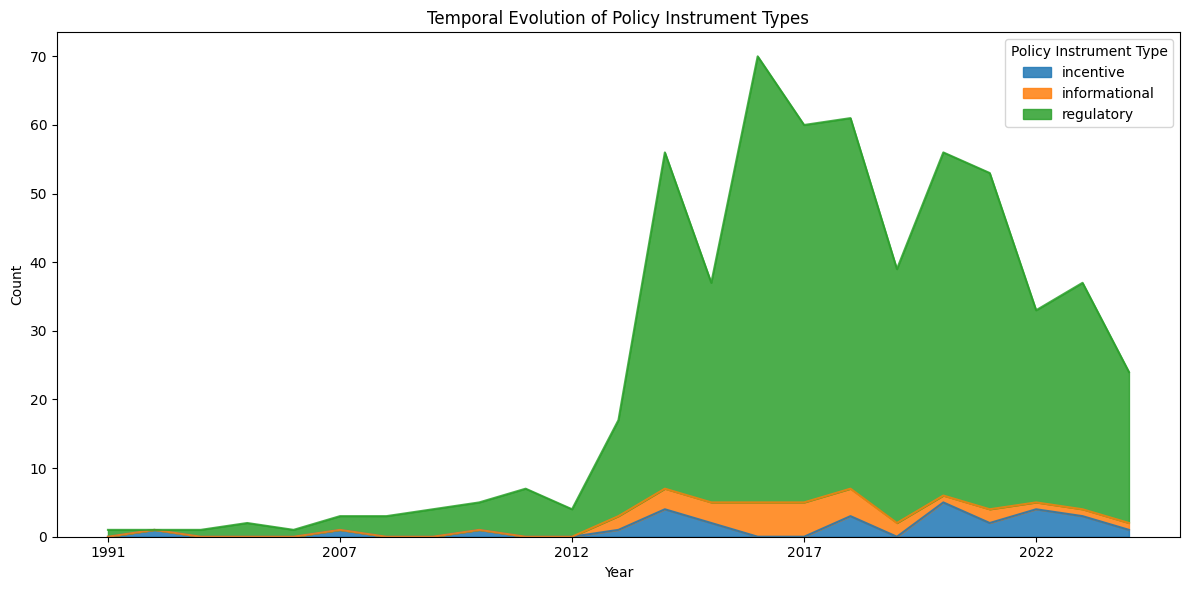

In [ ]:
# 3. plot area chart
import matplotlib.pyplot as plt


ax = pivot_year_tool.plot(
    kind="area",
    stacked=True,
    figsize=(12, 6),
    alpha=0.85
)

ax.set_title("Temporal Evolution of Policy Instrument Types")
ax.set_ylabel("Count")
ax.set_xlabel("Year")
plt.legend(title="Policy Instrument Type")
plt.tight_layout()
plt.show()

***结果与分析***

（1）**现象观察**
总体来看，监管型政策在各年份中长期占主导地位；激励型政策近年呈现上升趋势，而信息型政策的数量仍相对有限。

（2）**机制解释**
这一结构反映出浙江省县域治理仍主要依赖行政手段，激励与信息工具更多作为补充。随着生态文明建设与考核机制逐步完善，地方政府对激励性工具的采用明显增加。

（3）**政策启示**
县域层面的治理工具结构仍有优化空间。未来可在保持监管力度的同时，引入更多财政激励、市场化机制和信息公开措施，以提升治理效果并促进政策协同。

***Findings and Discussion***

(1) **Observation**
Regulatory instruments remain dominant across most years, while incentive-based instruments have increased in recent years. Informational instruments are relatively less frequent.

(2) **Interpretation**
This pattern suggests that local water governance in Zhejiang continues to rely primarily on administrative regulation, with incentives and information playing complementary roles. The recent rise in incentive instruments is likely associated with strengthened ecological performance evaluation and related policy reforms.

(3) **Implication**
There is room for further diversification of policy instruments. Future policy design may enhance sustainability and policy synergy by combining necessary regulatory measures with fiscal incentives, market-based tools, and information disclosure mechanisms.

### 8.2 县域政策工具结构对比
从空间维度对县域政策工具结构进行比较，重点分析各县在监管、激励与信息工具使用上的侧重差异，以识别县域治理模式在工具组合上的不同倾向。

### 8.2 County-level Comparison of Policy Instrument Structures
This section compares the structure of policy instruments across counties, focusing on regional variations in the use of regulatory, incentive, and informational instruments. The analysis highlights spatial differences in policy preferences and governance approaches at the county level.

In [ ]:
# 1. count by county and tool type
county_tool_counts = (
    df.groupby(["county", "tool"])
      .size()
      .reset_index(name="count")
      .sort_values(["county", "tool"])
)

county_tool_counts.head()

,county,tool,count
0,三门县,regulatory,11
1,上城区,incentive,1
2,上城区,regulatory,7
3,临安,regulatory,4
4,临平区,incentive,2


In [ ]:
# 2. pivot table for county × tool
pivot_county_tool = (
    county_tool_counts
    .pivot(index="county", columns="tool", values="count")
    .fillna(0)
    .sort_index()
)

pivot_county_tool.head()

tool,incentive,informational,regulatory
county,,,
三门县,0.0,0.0,11.0
上城区,1.0,0.0,7.0
临安,0.0,0.0,4.0
临平区,2.0,0.0,10.0
临海市,0.0,1.0,12.0


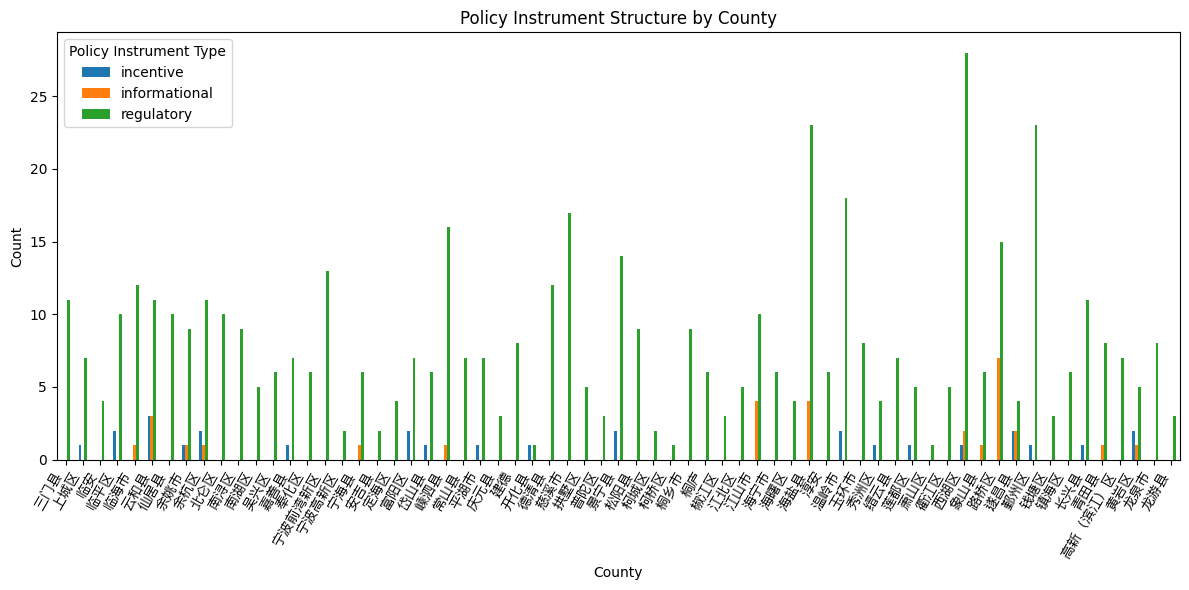

In [20]:
# 3. plot bar chart
ax = pivot_county_tool.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title("Policy Instrument Structure by County")
ax.set_ylabel("Count")
ax.set_xlabel("County")
plt.xticks(rotation=60, ha="right", fontproperties="PingFang HK")
plt.legend(title="Policy Instrument Type")
plt.tight_layout()
plt.show()

***结果与分析***

（1）**现象观察**
不同县域在政策工具使用上呈现显著差异。大多数县域以监管型政策为主，激励型和信息型工具整体较少；也有少数县在激励性工具方面表现更为突出。

（2）**机制解释**
这种差异可能源自各县的产业结构、环境压力以及治理资源的不同。经济活动较为集中的县域往往强调监管与执法手段，而资源型和生态功能区县域可能更倾向采用补贴、扶持等激励政策。

（3）**政策启示**
在推进区域协同治理过程中，可结合县域功能定位与治理需求，引导不同地区在监管、激励和信息工具之间构建更为均衡的政策组合，从而提高治理协同性与政策效能。

***Findings and Discussion***

(1) **Observation**
There are clearly visible differences across counties. Most counties rely predominantly on regulatory instruments, with relatively fewer incentive and informational tools, while a small number of counties make more extensive use of incentive instruments.

(2) **Interpretation**
These patterns may be associated with differences in industrial structure, environmental pressures, and administrative capacity. Economically intensive counties tend to emphasize regulatory enforcement, whereas resource-based or ecological counties may adopt more incentive-based measures.

(3) **Implication**
For coordinated regional governance, it is necessary to tailor policy design to the functional roles and governance needs of different counties and promote a more balanced combination of regulatory, incentive, and informational instruments to improve policy synergy and effectiveness.

Save for further analysis


In [21]:
import os

os.makedirs("output/visual", exist_ok=True)

year_tool_counts.to_csv(
    "output/visual/year_tool_counts.csv",
    index=False,
    encoding="utf-8-sig"
)

county_tool_counts.to_csv(
    "output/visual/county_tool_counts.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved to output/visual/year_tool_counts.csv and county_tool_counts.csv")

Saved to output/visual/year_tool_counts.csv and county_tool_counts.csv
